<a href="https://colab.research.google.com/github/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/ML-AI/generate-training-data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
#
#  Copyright 2025 United Kingdom Research and Innovation
#  Copyright 2025 Bangor University
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by:    Franck Vidal (UKRI-STFC) & Iwan Mitchell (Bangor University)

![gVXR](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/img/Logo-transparent-small.png?raw=1)

# Multi-material example: Section of electric cable

Up to now, we generated 2D radiographs. 
This time we are going to simulate the computed tomography (CT) acquisition of a section of electric cable. 
A cone-beam geometry is used. 
To keep it simple, we consider an ideal case: no scintillation, no point-spread function (PSF), and a monochromatic spectrum.

We will use CIL to reconstruct the CT data with the traditional FDK algorithm.

![Volume rendering of the CT data](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/output_data/multi_material-CT_scan/k3d_screenshot-volume_rendering.png?raw=1)

<div class="alert alert-block alert-warning">
    <b>Note:</b> Make sure the Python packages are already installed. See <a href="../README.md">README.md</a> in the root directory of the repository. If you are running this notebook from Google Colab, please run the cell below to install the required packages.
</div>

## Aims of this session

1. Understand the notion of pixel size in the context of a cone-beam geometry and how the magnification affects it.
2. Use OpenSCAD to generate a section of electric cable and save the geometries in STL files.
3. Combine two models made of two different types of material, one chemical element (copper), one a compound (PVC).
4. Simulate an ideal cone-beam computed tomography (CBCT) scan acquisition based on an actual experiment performed with the [Dual Tube High Energy (DTHE) device](https://doi.org/10.1016/j.tmater.2024.100030) by [RX Solutions](https://www.rx-solutions.com/) at [INSA Lyon](https://www.insa-lyon.fr/).
5. Demonstrate how to reconstruct the corresponding CT volume with the [Core Imaging Library (CIL)](https://github.com/TomographicImaging/CIL).
6. Save the reconstructed slices as a TIFF stack using 16-bit unsigned integers.
7. Explore the reconstructed volume and illustrate the partial view artefacts due to the partial view effect on the first and last slices.
8. Use [K3D Jupyter](https://github.com/K3D-tools/K3D-jupyter) to interactively visualise the data with volume rendering.

![Screenshot of the 3D environment using K3D](https://github.com/TomographicImaging/gVXR-Tutorials/blob/main/notebooks/output_data/multi_material-CT_scan/k3d_screenshot-cropped.png?raw=1)

In [2]:
import sys

import numpy as np

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q condacolab
    import condacolab
    condacolab.install()

    !conda install -y -c conda-forge -c https://software.repos.intel.com/python/conda -c ccpi cil=24.2.0 ipp=2021.12 astra-toolbox=*=cuda* tigre k3d

    !apt-get install -y openscad
    !pip install gvxr viewscad

    import os, urllib.request

    if not os.path.exists("../../data/Wire-Cu-2mm-17.54umvx"):
        os.makedirs("../../data/Wire-Cu-2mm-17.54umvx")

    files = ["../../data/Wire-Cu-2mm-17.54umvx/Proj/img_00000.tif",
            "notebooks/gvxr2json.py",
            ]

    url = "https://github.com/TomographicImaging/gVXR-Tutorials/raw/refs/heads/main/../data/Wire-Cu-2mm-17.54umvx/img_00000.tif"
    print("Download", url)
    urllib.request.urlretrieve(url, "../../data/Wire-Cu-2mm-17.54umvx/Proj/img_00000.tif")

    url = "https://github.com/TomographicImaging/gVXR-Tutorials/raw/refs/heads/main/../data/Wire-Cu-2mm-17.54umvx/unireconstruction.xml"
    print("Download", url)
    urllib.request.urlretrieve(url, "../data/Wire-Cu-2mm-17.54umvx/unireconstruction.xml")

    
    url = "https://github.com/TomographicImaging/gVXR-Tutorials/raw/refs/heads/main/notebooks/gvxr2json.py"
    print("Download", url)
    urllib.request.urlretrieve(url, "gvxr2json.py")

## Summary of the simulation parameters

| Parameters | Values | Units | Function call |
|------------|--------|-------|---------------|
| Source to object distance | 60.9223 | mm | `gvxr.setSourcePosition(...)` |
| Source type (beam shape) | Point source (cone beam) | | `gvxr.usePointSource()` |
| Beam spectrum | Monochromatic: 16,000 photons of 100 | keV | `gvxr.setMonoChromatic(...)` |
| Source to detector distance | 521.047 | mm | `gvxr.setDetectorPosition(...)` |
| Detector orientation | [0, 0, 1] |  | `gvxr.setDetectorUpVector(...)` |
| Detector resolution | 1912 &times; 1912 | pixels | `gvxr.setDetectorNumberOfPixels(...)` |
| Pixel spacing | 150 &times; 150 | um | `gvxr.setDetectorPixelSize(...)` |

## Import packages

- `os` to create the output directory if needed
- `matplotlib` to show 2D images
- `viewscad` to use OpenSCAD and create STL files
- `base64` to use save a screenshot of the K3D visualisation
- `tifffile.imread` to read the X-ray projection of the real experiment
- `xml.etree.ElementTree` to read the scanning parameters of the real experiment
- `gvxrPython3.gvxr` to simulate X-ray images
- `gvxrPython3.visualise` to use K3D to visualise the 3D environment
- `gvxrPython3.gVXRDataReader` to read the simulated data and prepare it for CIL
- `cil.recon.FDK` to reconstruct the CT volume using the FDK algorithm (3D-CBCT only) 
- `cil.recon.FBP` to reconstruct the CT volume using the FBP algorithm (2D/3D parallel geometry only) 
- `cil.io.TIFFWriter` to save the reconstructed slices as a TIFF stack
- `cil.processors.TransmissionAbsorptionConverter` to normalise the data and apply the minus log
- `cil.utilities.display.show_geometry` to display the acquisition geometry
- `cil.utilities.display.show2D` to show static 2D images
- `cil.utilities.jupyter.islicer` to show and navigate a stack of 2D images using a slider
- `cil.utilities.jupyter.link_islicer` to compare and navigate stacks of 2D images using a slider

In [3]:
from math import floor
import matplotlib # To plot images
import matplotlib.pyplot as plt # Plotting

font = {'family' : 'serif',
         'size'   : 15
       }
matplotlib.rc('font', **font)

# Uncomment the line below to use LaTeX fonts
# matplotlib.rc('text', usetex=True)

from tifffile import imread #, imwrite
from PIL import Image

import xml.etree.ElementTree as ET

from gvxrPython3 import gvxr
# from gvxrPython3.utils import has_k3d, visualise

from gvxrPython3.gVXRDataReader import *

from cil.recon import FDK # For CBCT

from cil.io import TIFFWriter

from cil.processors import TransmissionAbsorptionConverter
from cil.utilities.display import show_geometry, show2D
from cil.utilities.jupyter import islicer, link_islicer

from scipy import signal

In [4]:
create_labels = True

## 1. Pixel size and magnification in X-ray radiography

There are two different notions of pixel size that are used in digital radiography. They measure different quantities: 

- The first one may be refered as "pixel pitch". It is the physical distance between the centre of one pixel to the centre of the next on the detector. The pixel pitch is usually measured in &mu;m. In the DICOM standar used in medical imaging, it is called "Imager Pixel Spacing (IPS)".
- The second one is called "pixel spacing". It is the physical distance between the centre of one pixel to the centre of the next in the object. The pixel spacing is usually measured in mm.

The difference between the two values is due to the magnification.

<div class="alert alert-block alert-warning">
    <b>Note:</b> To myself, add a diagram.
</div>

Read a projection from an experiment

In [5]:
imager_pixel_spacing_in_um = np.array([150, 150])
raw_reference = np.array(imread("../../data/Wire-Cu-2mm-17.54umvx/Proj/img_00000.tif"), dtype=np.single)
raw_reference /= raw_reference.max()

Display the experimental image using the pixel size as the distance between two successive pixels on the detector.

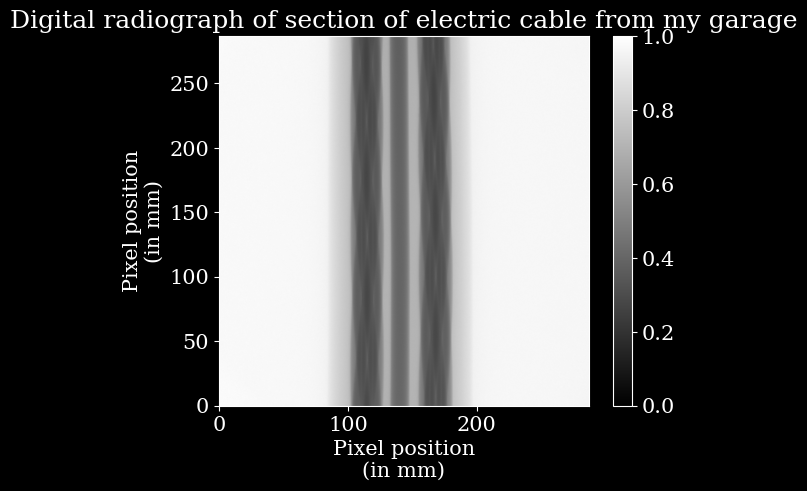

In [6]:
vmin=0.0
vmax=1.0

fig = plt.figure()
plt.imshow(raw_reference, cmap="gray", vmin=vmin, vmax=vmax,
                             extent=(0, (raw_reference.shape[1]-1)*imager_pixel_spacing_in_um[0]/1000.0,
                                     0, (raw_reference.shape[0]-1)*imager_pixel_spacing_in_um[1]/1000.0))
plt.title("Digital radiograph of section of electric cable from my garage")
plt.xlabel("Pixel position\n(in mm)")
plt.ylabel("Pixel position\n(in mm)")
plt.colorbar()
plt.show()

Looking at the image above, it seems that the width of the electric cable section in a bit more than 100 mm, i.e. 10 cm, which is obviously wrong. To address this is, we can take into acount the magnification due to the cone-beam geometry to retrieve the pixel size on the object plane. This is the technique used in medical imaging to determine the size of anatomic structures from 2D digital radiographs (DRs).

Read the parameters from the experiment

In [7]:
tree = ET.parse('../../data/Wire-Cu-2mm-17.54umvx/unireconstruction.xml')
root = tree.getroot()

geometry_branch = root.findall('conebeam/acquisitioninfo/geometry')[0]
sod = float(geometry_branch.attrib["sod"])
sdd = float(geometry_branch.attrib["sdd"])

print("Source-Object Distance:", sod, "mm")
print("Source-Detector Distance:", sdd, "mm")

voxel_size_branch = root.findall('conebeam/volume_acquisition/voxelSize')[0]
voxel_size = [
    float(voxel_size_branch.attrib["X"]),
    float(voxel_size_branch.attrib["Y"]),
    float(voxel_size_branch.attrib["Z"])
]

size_branch = root.findall('conebeam/volume_acquisition/size')[0]
number_of_voxels = [
    int(size_branch.attrib["X"]),
    int(size_branch.attrib["Y"]),
    int(size_branch.attrib["Z"])
]

print("Voxel size:", voxel_size, "mm")
print("Number of voxels:", number_of_voxels)

Source-Object Distance: 60.9223 mm
Source-Detector Distance: 521.047 mm
Voxel size: [0.0175384, 0.0175384, 0.0175384] mm
Number of voxels: [1843, 1658, 1843]


Compute the magnification

$$magnification = \frac{SDD}{SOD}$$

with $SDD$ the source to detector distance and $SOD$ the source to object distance.

<div class="alert alert-block alert-warning">
    <b>Note:</b> To myself, add a diagram.
</div>

In [8]:
magnification = sdd / sod
print("Magnification:", magnification)

Magnification: 8.552648209276407


Compute the pixel size in the object plane

In [9]:
spacing_in_mm = (imager_pixel_spacing_in_um / magnification) / 1000.0
print("Pixel size:", spacing_in_mm, "mm")

Pixel size: [0.01753843 0.01753843] mm


Display the experimental image using the "pixel size" in the object plane rather than the detector plane.

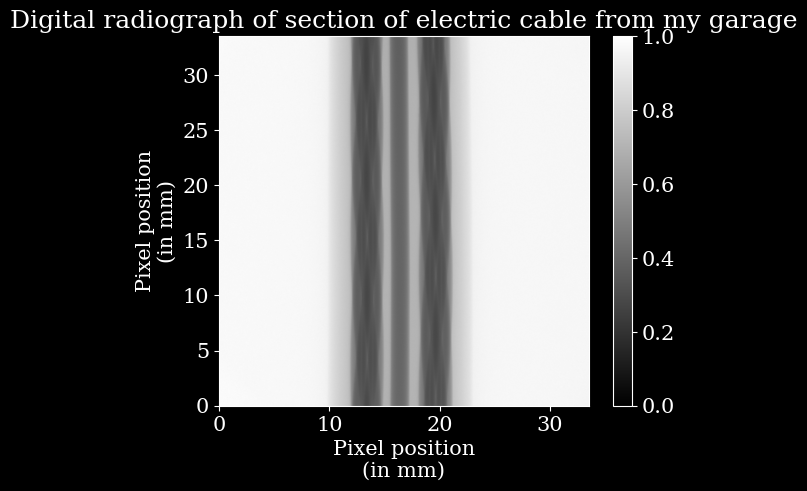

In [10]:
vmin=0.0
vmax=1.0

fig = plt.figure()
plt.imshow(raw_reference, cmap="gray", vmin=vmin, vmax=vmax,
                             extent=(0, (raw_reference.shape[1]-1)*spacing_in_mm[0],
                                     0, (raw_reference.shape[0]-1)*spacing_in_mm[1]))
plt.title("Digital radiograph of section of electric cable from my garage")
plt.xlabel("Pixel position\n(in mm)")
plt.ylabel("Pixel position\n(in mm)")
plt.colorbar()
plt.show()

Now the width of my electric cable is about 10mm, i.e. 1cm, which is about right.

## 2. OpenSCAD to generate a section of electric cable

Where to save the data

In [11]:
output_path = "../../notebooks/output_data/ML-AI"
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [12]:
wire_fname_stl = "../../data/Wire-Cu-2mm-17.54umvx/wires.stl"
insulation_fname_stl = "../../data/Wire-Cu-2mm-17.54umvx/insulation.stl"

## 3. Combining two models made of two different types of material

We use some of the parameters of an actual experiment performed with the [Dual Tube High Energy (DTHE) device](https://doi.org/10.1016/j.tmater.2024.100030) by [RX Solutions](https://www.rx-solutions.com/) at [INSA Lyon](https://www.insa-lyon.fr/). We start with the usual business, i.e. creating an OpenGL context, setting the parameters of the source and detector, and eventually load the new STL files.

In [13]:
# Create an OpenGL context
gvxr.createOpenGLContext()

# We increase the size of the visualisation framebuffer to generate higher resolution screenshots. It does not affect the simulation.
gvxr.setWindowSize(1000, 1000)

Thu Mar 26 16:58:16 2026 ---- Create window (ID: -1)
Thu Mar 26 16:58:16 2026 ---- Request an interactive OpenGL context
Thu Mar 26 16:58:16 2026 ---- Initialise GLFW
Thu Mar 26 16:58:16 2026 ---- Create an OpenGL window with a 4.3 context.
Thu Mar 26 16:58:16 2026 ---- Make the window's context current
Thu Mar 26 16:58:16 2026 (WW) GLAD was not initialised as it has been turned off.
Thu Mar 26 16:58:16 2026 ---- Initialise GLEW
Thu Mar 26 16:58:16 2026 ---- OpenGL vendor: NVIDIA Corporation
Thu Mar 26 16:58:16 2026 ---- OpenGL renderer: NVIDIA GeForce RTX 4060 Ti/PCIe/SSE2
Thu Mar 26 16:58:16 2026 ---- OpenGL version: 4.3.0 NVIDIA 580.119.02
Thu Mar 26 16:58:16 2026 ---- Use OpenGL 4.5.
Thu Mar 26 16:58:16 2026 ---- Use OpenGL Compute Shader.
Thu Mar 26 16:58:16 2026 ---- Initialise the X-ray renderer if needed and if possible


In [14]:
# Set the X-ray source position and shape
gvxr.setSourcePosition(0.0, sod, 0.0, "mm")
gvxr.usePointSource()

# Set the Spectrum
if create_labels:
    gvxr.setMonoChromaticPerPixelAtSDD(50, "keV", 16000)
else:
    voltage = float(root.findall('conebeam/acquisitioninfo/xray')[0].attrib["voltage"])
    gvxr.setVoltage(voltage, "kV")
    gvxr.addFilter("Cu", 2, "mm")

In [15]:
exposure_lookup_table = [0.067, 0.083, 0.111, 0.167, 0.333, 0.500] # [s]
exposure_ID = 5
current_in_uA = 199
exposure_time_in_sec = exposure_lookup_table[exposure_ID - 1]
mAs = exposure_time_in_sec * current_in_uA / 1000

gvxr.setmAs(mAs)

if create_labels:
    gvxr.disablePoissonNoise()
else:
    gvxr.enablePoissonNoise()

print("Exposure time:", exposure_time_in_sec, "in sec")
print("Exposure:", mAs, "mAs")

Exposure time: 0.333 in sec
Exposure: 0.066267 mAs


In [16]:
# Set the detector properties
scaling_factor = 1

gvxr.setDetectorPosition(0.0, -(sdd - sod), 0.0, "mm")
gvxr.setDetectorUpVector(0, 0, 1)

if create_labels:
    padding = 50
    gvxr.setDetectorNumberOfPixels(raw_reference.shape[1] // scaling_factor, 50 + 2 * padding) #raw_reference.shape[0] //
    # scaling_factor)
else:
    padding = 0
    gvxr.setDetectorNumberOfPixels(raw_reference.shape[1] // scaling_factor, 50 + 2 * padding) #raw_reference.shape[0] // scaling_factor)

gvxr.setDetectorPixelSize(imager_pixel_spacing_in_um[0] * scaling_factor,
                      imager_pixel_spacing_in_um[1] * scaling_factor,
                      "um")

Thu Mar 26 16:58:17 2026 ---- Initialise the renderer with 32 bits per floating-point numbers in GPU memory


The section of electric cable combine two models. One is made of copper, the other one of PVC. In the case of the chemical element, the density of the material can be omitted. This is not the case for the compound. The composition of PVC is C2H3Cl and density is ~1.3 g/cm<sup>3</sup>.

In [17]:
geometry_set = {
    "stealh": {"fname": insulation_fname_stl, "Compound": "C2H3Cl", "Density" : 1.3, "Colour" : [0.5, 0.5, 0.5, 1.0]},
    "wires": {"fname": wire_fname_stl, "Element": "Cu", "Colour" : [0.722, 0.451, 0.20, 1.0]},
}

translation_vector_in_mm = [0.0, -100.0, 0.0]
translation_vector_in_mm = [0.0, 0.0, 0.0]

gvxr.removePolygonMeshesFromSceneGraph()

for i, label in enumerate(geometry_set):
    gvxr.loadMeshFile(label, geometry_set[label]["fname"], "mm")

    # Chemical element
    if "Element" in geometry_set[label]:
        gvxr.setElement(label, geometry_set[label]["Element"])
    # Compound + density
    elif "Compound" in geometry_set[label] and "Density" in geometry_set[label]:
        gvxr.setCompound(label, geometry_set[label]["Compound"])
        gvxr.setDensity(label, geometry_set[label]["Density"], "g/cm3")
    # Mixture + density
    elif "Mixture" in geometry_set[label] and "Density" in geometry_set[label]:
        gvxr.setMixture(label, geometry_set[label]["Mixture"])
        gvxr.setDensity(label, geometry_set[label]["Density"], "g/cm3")
    # Hounsfield unit
    elif "HU" in geometry_set[label]:
        gvxr.setHounsfieldUnit(label, round(geometry_set[label]["HU"]))
    # Unsupported
    else:
        raise ValueError("Unknow material composition for " + label + " in " + str(geometry_set[label]))

    if create_labels:
        gvxr.setLinearAttenuationCoefficient(label, 0.1 * (i + 1), "cm-1")

    # Colour in the 3D visualisation
    if "Colour" in geometry_set[label]:
        gvxr.setColour(label,
            geometry_set[label]["Colour"][0],
            geometry_set[label]["Colour"][1],
            geometry_set[label]["Colour"][2],
            geometry_set[label]["Colour"][3])

    gvxr.scaleNode(label, 0.449648712, 0.449648712, 1)
    gvxr.translateNode(label, *translation_vector_in_mm, "mm")
    gvxr.applyCurrentLocalTransformation(label)

Thu Mar 26 16:58:17 2026 ---- file_name:	../../data/Wire-Cu-2mm-17.54umvx/insulation.stl	nb_faces:	28720	nb_vertices:	86160	bounding_box (in cm):	(-1.5, -0.5, -5.05)	(1.5, 0.5, 5.05)
Thu Mar 26 16:58:17 2026 ---- file_name:	../../data/Wire-Cu-2mm-17.54umvx/wires.stl	nb_faces:	28324	nb_vertices:	84972	bounding_box (in cm):	(-1.1, -0.299944, -6)	(1.1, 0.299944, 6)


We are now ready to compute an X-ray image and display it.

In [18]:
x_ray_image = np.array(gvxr.computeXRayImage(), dtype=np.single) / gvxr.getTotalEnergyWithDetectorResponse();

We can display it side-by-side with the experimental image. The images will look different because:

- The material compositions we used in the simulation correspond to theorical values. They are likely to differ from the material used to manufacture the electric cable.
- The simulated source is monochromatic. This is not realistic.
- The simulated sample is a CAD model, not generated from the segmentation of the experimental CT volume, we'll see why later.

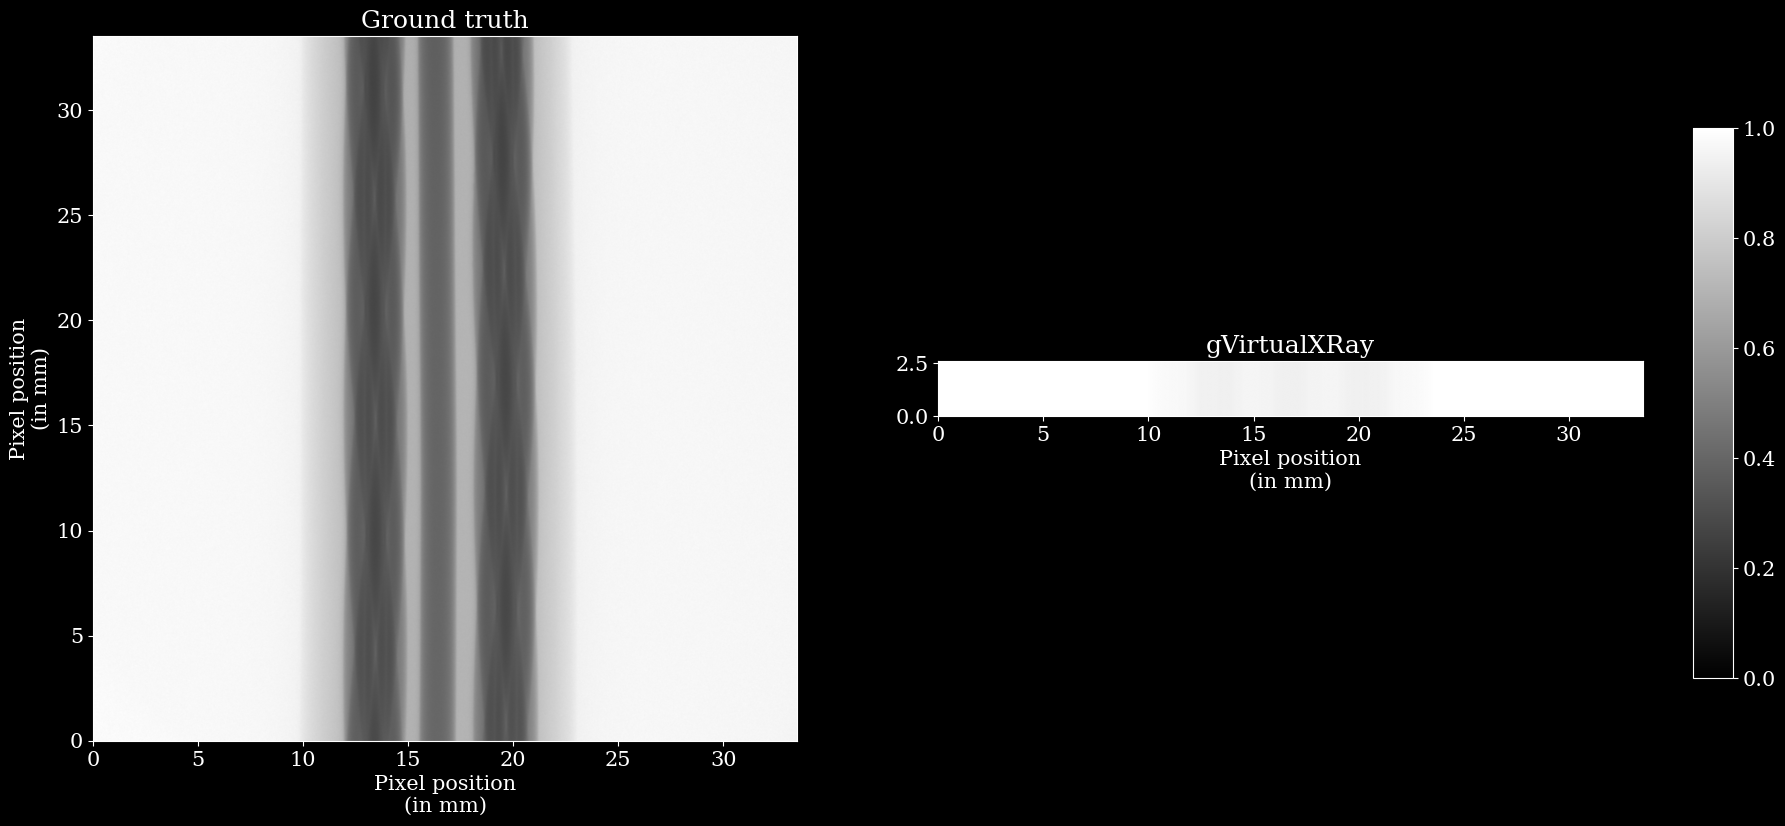

In [19]:
vmin = 0.0
vmax = 1.0

# Plot the two images side-by-side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 20))

im1 = axes.flat[0].imshow(raw_reference, cmap="gray", vmin=vmin, vmax=vmax,
    extent=[0,(raw_reference.shape[1]-1)*spacing_in_mm[0],0,(raw_reference.shape[0]-1)*spacing_in_mm[1]])
axes.flat[0].set_title("Ground truth")


im2 = axes.flat[1].imshow(x_ray_image, cmap="gray", vmin=vmin, vmax=vmax,
    extent=[0,(x_ray_image.shape[1]-1)*spacing_in_mm[0]*scaling_factor,0,(x_ray_image.shape[0]-1)*spacing_in_mm[1]*scaling_factor])
axes.flat[1].set_title("gVirtualXRay")

axes.flat[0].set_xlabel("Pixel position\n(in mm)")
axes.flat[1].set_xlabel("Pixel position\n(in mm)")
axes.flat[0].set_ylabel("Pixel position\n(in mm)")

cb_ax = fig.add_axes((0.925, 0.35, 0.02, 0.275))
cbar = fig.colorbar(im1, cax=cb_ax)
plt.show()

It may be useful to visualise the 3D environment to ascertain everything is as expected. It can be done in a window or offscreen with a screenshot.
We use both the functionality built in gVXR and K3D

We use k3D if possible. It's a nice 3D visualisation framework for Jupyter notebooks.

## 4. Compute the X-ray projections for a CT acquisition

Only generate a few slices. It should be enough.

In [20]:
gvxr.getDetectorNumberOfPixels()

(1912, 150)

In [21]:
# gvxr.setDetectorNumberOfPixels(gvxr.getDetectorNumberOfPixels()[0], 1000)

In [22]:
# gvxr.renderLoop()

In [23]:
number_of_projections = 1472
# number_of_projections = 30

if create_labels:
    proj_path = os.path.join(output_path, "projections-labels-" + str(number_of_projections))
    CT_path = os.path.join(output_path, "labels-" + str(number_of_projections))
else:
    proj_path = os.path.join(output_path, "projections-" + str(number_of_projections))
    CT_path = os.path.join(output_path, "recons-" + str(number_of_projections))

In [24]:

gvxr.computeCTAcquisition(proj_path, # the path where the X-ray projections will be saved.
                              # If the path is empty, the data will be stored in the main memory, but not saved on the disk.
                              # If the path is provided, the data will be saved on the disk, and the main memory released.
                          os.path.join(output_path, "screenshots-" + str(number_of_projections)), # the path where the
                          # screenshots will be saved.
                              # If kept empty, not screenshot will be saved.
                          number_of_projections, # The total number of projections to simulate.
                          0, # The rotation angle corresponding to the first projection.
                          True, # A boolean flag to include or exclude the last angle. It is used to calculate the angular step between successive projections.
                          360,
                          50, # The number of white images used to perform the flat-field correction. If zero, then
                          # no correction will be performed.
                          *translation_vector_in_mm, # The location of the rotation centre.
                          "mm", # The corresponding unit of length.
                          *gvxr.getDetectorUpVector(), # The rotation axis
                          True # If true the energy fluence is returned, otherwise the number of photons is returned
                               # (default value: true)
)

## 5. Demonstrate how to reconstruct the corresponding CT volume with the [Core Imaging Library (CIL)](https://github.com/TomographicImaging/CIL).

In [25]:
# print(gvxr.getDetectorPositionSet("mm"))
print(gvxr.getDetectorPosition("mm"))
print(gvxr.getDetectorUpVector())
print(gvxr.getSourcePosition("mm"))
print(translation_vector_in_mm)


(0.0, -460.12469482421875, 0.0)
(0.0, 0.0, 1.0)
(0.0, 60.922298431396484, 0.0)
[0.0, 0.0, 0.0]


In [26]:
# Read the simulated data with CIL.
reader = gVXRDataReader(proj_path, gvxr.getAngleSetCT(),
                        np.array(translation_vector_in_mm) * -1)
data = reader.read()

[1912  150]
[0.15000000957664586, 0.15000000957664586]


In [27]:
print("data.geometry", data.geometry)

data.geometry 3D Cone-beam tomography
System configuration:
	Source position: [ -0.        , -60.92229843,  -0.        ]
	Rotation axis position: [-0., -0., -0.]
	Rotation axis direction: [0., 0., 1.]
	Detector position: [ -0.        , 460.12469482,  -0.        ]
	Detector direction x: [-1., -0.,  0.]
	Detector direction y: [-0., -0., -1.]
Panel configuration:
	Number of pixels: [1912  150]
	Pixel size: [0.15000001 0.15000001]
	Pixel origin: bottom-left
Channel configuration:
	Number of channels: 1
Acquisition description:
	Number of positions: 1472
	Angles 0-9 in degrees: [0.        , 0.24473147, 0.48946294, 0.7341944 , 0.9789259 , 1.2236574 ,
 1.4683888 , 1.7131203 , 1.9578518 , 2.2025833 ]
	Angles 1462-1471 in degrees: [357.79742, 358.04214, 358.28687, 358.53162, 358.77634, 359.02106,
 359.2658 , 359.51053, 359.75525, 360.     ]
	Full angular array can be accessed with acquisition_data.geometry.angles
Distances in units: units distance


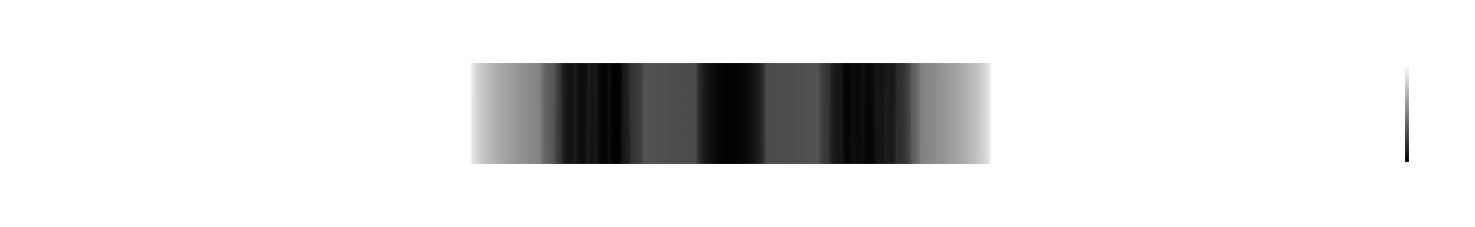

In [28]:
show2D(data)

In [29]:
islicer(data)

In [30]:
data_corr = TransmissionAbsorptionConverter(white_level=data.max())(data)

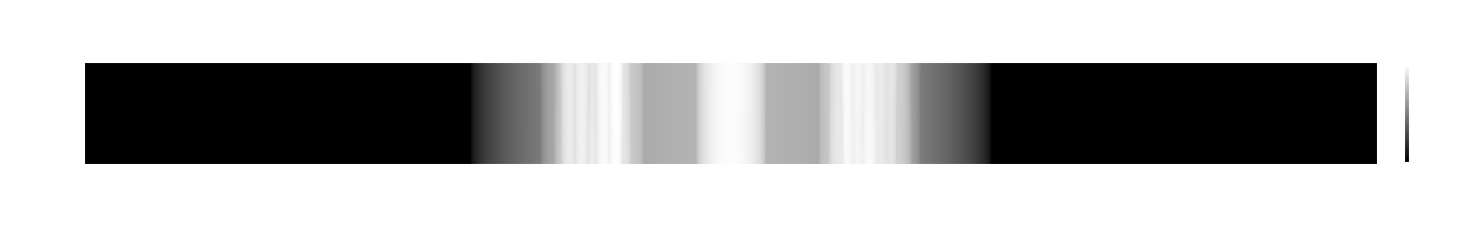

In [31]:
show2D(data_corr)

In [32]:
islicer(data_corr)

In [33]:
data_corr.reorder(order='tigre')

In [34]:
ig = data_corr.geometry.get_ImageGeometry()

ig.voxel_num_x = ig.voxel_num_x // 2
ig.voxel_size_x *= 2.0

ig.voxel_num_y = ig.voxel_num_y // 2
ig.voxel_size_y *= 2.0

ig.voxel_num_z = ig.voxel_num_z - 2 * padding


print("Image geometry", ig)

Image geometry Number of channels: 1
channel_spacing: 1.0
voxel_num : x956,y956,z50
voxel_size : x0.0350768566614016,y0.0350768566614016,z0.0175384283307008
center : x0,y0,z0



In [35]:
# Perform the reconstruction with CIL
FDK_reconstruction = FDK(data_corr, ig).run()

FDK recon

Input Data:
	angle: 1472
	vertical: 150
	horizontal: 1912

Reconstruction Volume:
	vertical: 50
	horizontal_y: 956
	horizontal_x: 956

Reconstruction Options:
	Backend: tigre
	Filter: ram-lak
	Filter cut-off frequency: 1.0
	FFT order: 12
	Filter_inplace: False



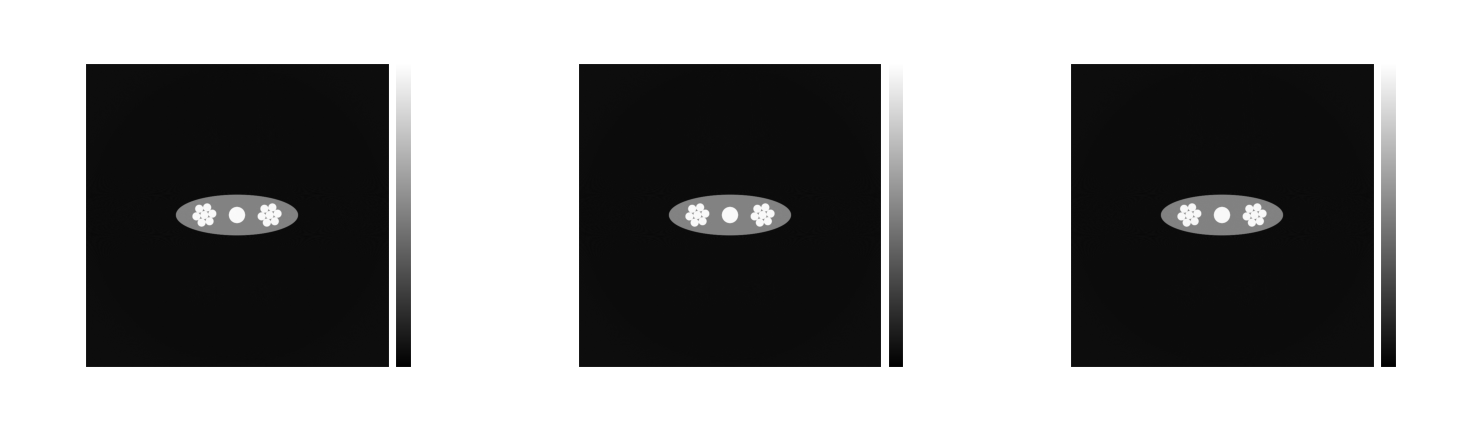

In [36]:
# Look at partial view artefacts
show2D(FDK_reconstruction, slice_list=[1, FDK_reconstruction.shape[0] // 2, FDK_reconstruction.shape[0] - 2], title=["2nd slice", "Middle slice", "Slice before last"], num_cols=3)

## 6. Save the reconstructed slices as a TIFF stack using 16-bit unsigned integers.


In [37]:
labels = np.zeros(FDK_reconstruction.shape, dtype=np.uint8)

counts, bins = np.histogram(FDK_reconstruction.array.flatten(), 1 + len(geometry_set))
half_bin_size = (bins[1] - bins[0]) / 2.0

if not os.path.exists(CT_path):
    os.makedirs(CT_path)

min_value = np.min(FDK_reconstruction.array)
max_value = np.max(FDK_reconstruction.array)
value_range = max_value - min_value

print("Images are saved in:", CT_path)
for i, (CT_image, labelled_image) in enumerate(zip(FDK_reconstruction.array, labels)):
    if create_labels:
        for j in range(len(bins) - 1):
            mu = bins[j + 1]
            filtered_image = signal.medfilt2d(CT_image, kernel_size=5)
            selection1 = filtered_image > mu - half_bin_size
            selection2 = filtered_image <= mu + half_bin_size
            labelled_image[selection1 & selection2] = j
        # imwrite(CT_path + str(i).zfill(4) + ".tiff", labelled_image)
        PIL_image = Image.fromarray(labelled_image)
        PIL_image.save(os.path.join(CT_path, "slice_" + str(i).zfill(4) + ".png"))
    else:
        uint16_data = np.iinfo('uint16').max * (CT_image.astype(np.single) - min_value) / value_range

        PIL_image = Image.fromarray(uint16_data.astype(np.uint16))
        PIL_image.save(os.path.join(CT_path, "slice_" + str(i).zfill(4) + ".png"))

Images are saved in: ../../notebooks/output_data/ML-AI/labels-1472


In [38]:
# Save the reconstructed CT images
if not create_labels:
    writer = TIFFWriter(data=FDK_reconstruction, file_name=os.path.join(CT_path, "slice_"))
    writer.write();

## 7. Explore the reconstructed volume and illustrate the partial view artefacts due to the partial view effect on the first and last slices.

In [39]:
islicer(FDK_reconstruction)

# Cleaning up

Once we have finished, it is good practice to clean up the OpenGL contexts and windows with the following command. Note that due to the object-oriented programming nature of the core API of gVXR, this step is automatic anyway.

In [40]:
gvxr.destroy();

Thu Mar 26 16:59:48 2026 ---- Release all the memory
Thu Mar 26 16:59:48 2026 ---- Destroy all the windows
Thu Mar 26 16:59:48 2026 ---- Destroy window 0(0x55a557489b20)
